# Factor Attribution & Performance Decomposition

**CQF-Level Example**: Portfolio return attribution:
- Brinson attribution (allocation vs selection)
- Factor-based attribution (CAPM, Multi-factor)
- Holdings-based vs returns-based attribution
- Alpha/Beta decomposition
- Sector contribution analysis

**Connectors Used:**
- `qj.eod` - Holdings prices
- `qj.fmp` - Sector information
- `qj.ff` - Fama-French factors

**API:** https://api.quantjourney.cloud

In [1]:
# Setup
import sys
sys.path.insert(0, '..')

from quantjourney.sdk import QuantJourneyAPI
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.default = "png"

import os
API_KEY = os.environ.get("QJ_API_KEY", "qj_...")

qj = QuantJourneyAPI(api_key=API_KEY)
print("✓ Connected to QuantJourney API")


✓ Connected to QuantJourney API


## 1. Define Portfolio & Benchmark

In [3]:
# Portfolio with sector assignments
portfolio = {
    'AAPL': {'weight': 0.15, 'sector': 'Technology'},
    'MSFT': {'weight': 0.12, 'sector': 'Technology'},
    'GOOGL': {'weight': 0.10, 'sector': 'Technology'},
    'JPM': {'weight': 0.10, 'sector': 'Financials'},
    'BAC': {'weight': 0.05, 'sector': 'Financials'},
    'JNJ': {'weight': 0.08, 'sector': 'Healthcare'},
    'UNH': {'weight': 0.07, 'sector': 'Healthcare'},
    'XOM': {'weight': 0.08, 'sector': 'Energy'},
    'CVX': {'weight': 0.05, 'sector': 'Energy'},
    'PG': {'weight': 0.08, 'sector': 'Consumer'},
    'KO': {'weight': 0.05, 'sector': 'Consumer'},
    'CAT': {'weight': 0.07, 'sector': 'Industrials'},
}

# S&P 500 sector weights (benchmark)
benchmark_sectors = {
    'Technology': 0.29,
    'Financials': 0.13,
    'Healthcare': 0.13,
    'Energy': 0.04,
    'Consumer': 0.10,
    'Industrials': 0.08,
    'Other': 0.23
}

symbols = list(portfolio.keys())
print(f"Portfolio: {len(symbols)} positions")


Portfolio: 12 positions


In [4]:
# Fetch prices
prices = {}
for symbol in symbols + ['SPY']:  # Include benchmark
    try:
        response = qj.eod.get_historical_prices(
            symbol=symbol,
            start_date='2022-01-01',
            end_date='2024-12-31',
            frequency='1d'
        )
        data = response.get('value', response) if isinstance(response, dict) else response
        if isinstance(data, list) and len(data) > 0:
            df = pd.DataFrame(data)
            df['date'] = pd.to_datetime(df['date'])
            df = df.set_index('date')
            prices[symbol] = df['adjusted_close' if 'adjusted_close' in df.columns else 'close']
            print(f"✓ {symbol}")
    except Exception as e:
        print(f"✗ {symbol}: {e}")

# Fallback
if len(prices) < 5:
    print("\nGenerating synthetic data...")
    dates = pd.date_range(start='2022-01-01', end='2024-12-31', freq='B')
    np.random.seed(42)
    
    for sym in symbols + ['SPY']:
        ret = 0.08/252 + 0.20/np.sqrt(252) * np.random.randn(len(dates))
        prices[sym] = pd.Series(100 * np.cumprod(1 + ret), index=dates)


✓ AAPL
✓ MSFT
✓ GOOGL
✓ JPM
✓ BAC
✓ JNJ
✓ UNH
✓ XOM
✓ CVX
✓ PG
✓ KO
✓ CAT
✓ SPY


In [5]:
# Calculate returns
prices_df = pd.DataFrame(prices).dropna()
returns_df = prices_df.pct_change().dropna()

# Portfolio weights
weights = pd.Series({sym: portfolio[sym]['weight'] for sym in symbols})
sectors = pd.Series({sym: portfolio[sym]['sector'] for sym in symbols})

# Portfolio returns
port_returns = (returns_df[symbols] * weights).sum(axis=1)
bench_returns = returns_df['SPY']

print(f"\nPeriod: {returns_df.index.min().date()} to {returns_df.index.max().date()}")



Period: 2022-01-04 to 2024-12-31


## 2. Total Return Attribution

In [6]:
# Calculate cumulative returns
port_cumulative = (1 + port_returns).cumprod() - 1
bench_cumulative = (1 + bench_returns).cumprod() - 1
active_return = port_cumulative - bench_cumulative

print(f"Total Return Attribution:")
print(f"  Portfolio: {port_cumulative.iloc[-1]*100:.1f}%")
print(f"  Benchmark: {bench_cumulative.iloc[-1]*100:.1f}%")
print(f"  Active Return: {active_return.iloc[-1]*100:.1f}%")


Total Return Attribution:
  Portfolio: 40.6%
  Benchmark: 28.2%
  Active Return: 12.4%


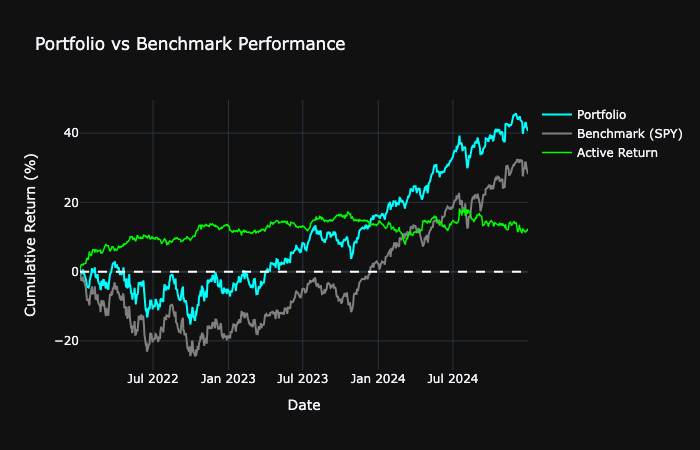

In [7]:
# Cumulative performance chart
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=port_cumulative.index, y=port_cumulative * 100,
    mode='lines', name='Portfolio', line=dict(color='cyan', width=2)
))
fig.add_trace(go.Scatter(
    x=bench_cumulative.index, y=bench_cumulative * 100,
    mode='lines', name='Benchmark (SPY)', line=dict(color='gray', width=2)
))
fig.add_trace(go.Scatter(
    x=active_return.index, y=active_return * 100,
    mode='lines', name='Active Return', line=dict(color='lime', width=1.5)
))

fig.add_hline(y=0, line_dash="dash", line_color="white")

fig.update_layout(
    title='Portfolio vs Benchmark Performance',
    xaxis_title='Date',
    yaxis_title='Cumulative Return (%)',
    template='plotly_dark',
    height=450
)
fig.show()


## 3. Brinson Attribution

In [8]:
# Calculate sector weights and returns
port_sector_weights = sectors.map(weights.groupby(sectors).sum())
port_sector_weights = weights.groupby(sectors).sum()

# Calculate sector returns for portfolio
sector_returns = {}
for sector in port_sector_weights.index:
    sector_stocks = [s for s in symbols if sectors[s] == sector]
    sector_wts = weights[sector_stocks] / weights[sector_stocks].sum()
    sector_returns[sector] = (returns_df[sector_stocks] * sector_wts).sum(axis=1)

sector_returns_df = pd.DataFrame(sector_returns)

# Use benchmark sector returns (SPY as proxy for all sectors here)
bench_sector_returns = {sector: bench_returns for sector in port_sector_weights.index}
bench_sector_returns_df = pd.DataFrame(bench_sector_returns)


In [9]:
# Brinson Attribution Components
# R_p - R_b = Allocation + Selection + Interaction

brinson = {}
for sector in port_sector_weights.index:
    wp = port_sector_weights[sector]  # Portfolio weight
    wb = benchmark_sectors.get(sector, 0.05)  # Benchmark weight
    rp = sector_returns_df[sector].mean() * 252  # Portfolio sector return (ann)
    rb = bench_sector_returns_df[sector].mean() * 252  # Benchmark sector return (ann)
    bench_total = bench_returns.mean() * 252
    
    # Allocation effect: (wp - wb) * (rb - R_benchmark)
    allocation = (wp - wb) * (rb - bench_total)
    
    # Selection effect: wb * (rp - rb)
    selection = wb * (rp - rb)
    
    # Interaction effect: (wp - wb) * (rp - rb)
    interaction = (wp - wb) * (rp - rb)
    
    brinson[sector] = {
        'Port Weight': wp,
        'Bench Weight': wb,
        'Port Return': rp,
        'Bench Return': rb,
        'Allocation': allocation,
        'Selection': selection,
        'Interaction': interaction,
        'Total': allocation + selection + interaction
    }

brinson_df = pd.DataFrame(brinson).T
print("\nBrinson Attribution by Sector (Annualized):")
print(brinson_df[['Port Weight', 'Bench Weight', 'Allocation', 'Selection', 'Interaction', 'Total']].round(4))



Brinson Attribution by Sector (Annualized):
             Port Weight  Bench Weight  Allocation  Selection  Interaction  \
Consumer            0.13          0.10         0.0    -0.0045      -0.0014   
Energy              0.13          0.04         0.0     0.0043       0.0097   
Financials          0.15          0.13         0.0     0.0058       0.0009   
Healthcare          0.15          0.13         0.0    -0.0110      -0.0017   
Industrials         0.07          0.08        -0.0     0.0122      -0.0015   
Technology          0.37          0.29         0.0     0.0119       0.0033   

              Total  
Consumer    -0.0059  
Energy       0.0140  
Financials   0.0067  
Healthcare  -0.0127  
Industrials  0.0107  
Technology   0.0151  


In [10]:
# Total Brinson Attribution
total_allocation = brinson_df['Allocation'].sum() * 100
total_selection = brinson_df['Selection'].sum() * 100
total_interaction = brinson_df['Interaction'].sum() * 100

print(f"\nTotal Attribution (bps):")
print(f"  Allocation Effect:  {total_allocation:+.0f} bps")
print(f"  Selection Effect:   {total_selection:+.0f} bps")
print(f"  Interaction Effect: {total_interaction:+.0f} bps")
print(f"  " + "-"*30)
print(f"  Total Active:       {total_allocation + total_selection + total_interaction:+.0f} bps")



Total Attribution (bps):
  Allocation Effect:  +0 bps
  Selection Effect:   +2 bps
  Interaction Effect: +1 bps
  ------------------------------
  Total Active:       +3 bps


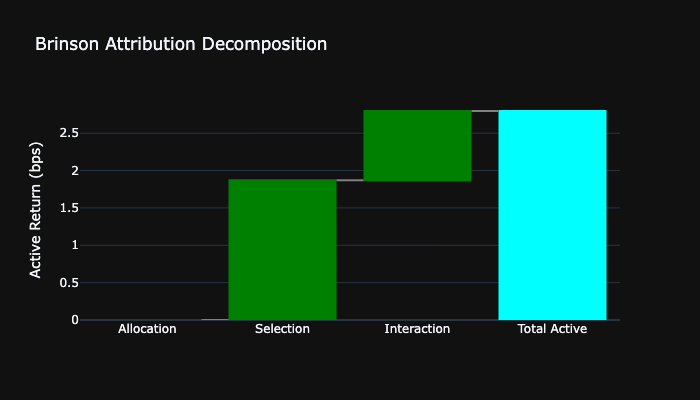

In [11]:
# Brinson waterfall chart
fig = go.Figure(go.Waterfall(
    name="Attribution",
    orientation="v",
    measure=["relative", "relative", "relative", "total"],
    x=["Allocation", "Selection", "Interaction", "Total Active"],
    y=[total_allocation, total_selection, total_interaction, 0],
    connector={"line": {"color": "gray"}},
    decreasing={"marker": {"color": "red"}},
    increasing={"marker": {"color": "green"}},
    totals={"marker": {"color": "cyan"}}
))

fig.update_layout(
    title='Brinson Attribution Decomposition',
    yaxis_title='Active Return (bps)',
    template='plotly_dark',
    height=400
)
fig.show()


## 4. Factor-Based Attribution

In [12]:
# Fetch Fama-French factors
try:
    ff_response = qj.ff.get_factors(factor_set="F-F_Research_Data_5_Factors_2x3", frequency="daily")
    ff_data = ff_response.get('value', ff_response) if isinstance(ff_response, dict) else ff_response
    ff_df = pd.DataFrame(ff_data)
    ff_df['date'] = pd.to_datetime(ff_df['date'])
    ff_df = ff_df.set_index('date')
    for col in ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']:
        if col in ff_df.columns:
            ff_df[col] = ff_df[col] / 100
    print(f"✓ Loaded Fama-French factors: {len(ff_df)} days")
except Exception as e:
    print(f"Generating synthetic factors...")
    ff_df = pd.DataFrame(index=returns_df.index)
    np.random.seed(42)
    ff_df['Mkt-RF'] = bench_returns
    ff_df['SMB'] = np.random.randn(len(ff_df)) * 0.005
    ff_df['HML'] = np.random.randn(len(ff_df)) * 0.005
    ff_df['RMW'] = np.random.randn(len(ff_df)) * 0.004
    ff_df['CMA'] = np.random.randn(len(ff_df)) * 0.004
    ff_df['RF'] = 0.04 / 252


Generating synthetic factors...


In [13]:
# Align data
common_idx = port_returns.index.intersection(ff_df.index)
port_excess = port_returns.loc[common_idx] - ff_df.loc[common_idx, 'RF']
factors = ff_df.loc[common_idx, ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']]

# OLS regression
def ols_regression(y, X):
    X_const = np.column_stack([np.ones(len(X)), X])
    beta = np.linalg.lstsq(X_const, y, rcond=None)[0]
    y_pred = X_const @ beta
    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - y.mean())**2)
    r2 = 1 - ss_res / ss_tot
    return beta, r2

betas, r2 = ols_regression(port_excess.values, factors.values)

print("\nFama-French 5-Factor Attribution:")
print(f"  Alpha (ann): {betas[0]*252*100:.2f}%")
print(f"  Market β:    {betas[1]:.3f}")
print(f"  SMB β:       {betas[2]:.3f}")
print(f"  HML β:       {betas[3]:.3f}")
print(f"  RMW β:       {betas[4]:.3f}")
print(f"  CMA β:       {betas[5]:.3f}")
print(f"  R²:          {r2:.3f}")



Fama-French 5-Factor Attribution:
  Alpha (ann): 0.17%
  Market β:    0.828
  SMB β:       0.017
  HML β:       0.033
  RMW β:       0.005
  CMA β:       -0.060
  R²:          0.853


In [14]:
# Return decomposition
factor_names = ['Alpha', 'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']
factor_means = [1] + factors.mean().tolist()  # 1 for alpha intercept
factor_contrib = betas * factor_means * 252 * 100  # Annualized contribution

decomp_df = pd.DataFrame({
    'Factor': factor_names,
    'Beta': [betas[0]*252] + betas[1:].tolist(),
    'Factor Return (ann)': [1] + [f*252*100 for f in factors.mean()],
    'Contribution (%)': factor_contrib
})

print("\nReturn Decomposition:")
print(decomp_df.round(3).to_string(index=False))
print(f"\nTotal Explained: {factor_contrib.sum():.2f}%")
print(f"Actual Return: {port_excess.mean()*252*100:.2f}%")



Return Decomposition:
Factor   Beta  Factor Return (ann)  Contribution (%)
 Alpha  0.002                1.000             0.168
Mkt-RF  0.828                9.857             8.159
   SMB  0.017               -2.629            -0.044
   HML  0.033               14.857             0.483
   RMW  0.005                0.732             0.003
   CMA -0.060                1.933            -0.116

Total Explained: 8.65%
Actual Return: 8.65%


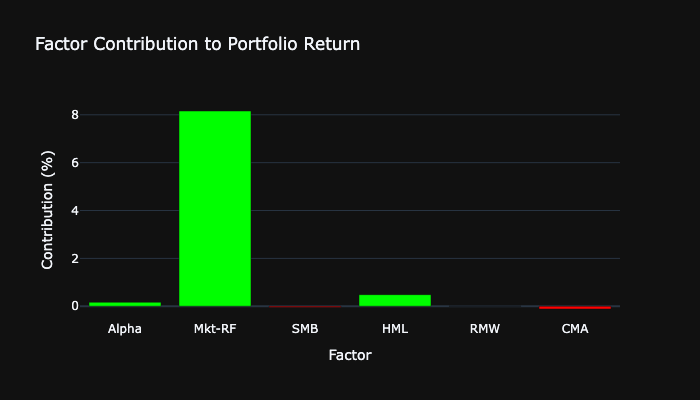

In [15]:
# Factor contribution chart
fig = go.Figure()

fig.add_trace(go.Bar(
    x=factor_names,
    y=factor_contrib,
    marker_color=['lime' if x > 0 else 'red' for x in factor_contrib]
))

fig.update_layout(
    title='Factor Contribution to Portfolio Return',
    xaxis_title='Factor',
    yaxis_title='Contribution (%)',
    template='plotly_dark',
    height=400
)
fig.show()


## 5. Stock-Level Attribution

In [16]:
# Individual stock contribution
stock_contrib = {}
for sym in symbols:
    stock_ret = returns_df[sym].mean() * 252  # Annualized
    contrib = weights[sym] * stock_ret * 100
    active_contrib = weights[sym] * (returns_df[sym] - bench_returns).mean() * 252 * 100
    stock_contrib[sym] = {
        'Weight': weights[sym] * 100,
        'Stock Return': stock_ret * 100,
        'Contribution': contrib,
        'Active Contrib': active_contrib,
        'Sector': sectors[sym]
    }

stock_df = pd.DataFrame(stock_contrib).T.round(2)
stock_df = stock_df.sort_values('Contribution', ascending=False)

print("\nStock-Level Attribution (Annualized):")
print(stock_df.to_string())



Stock-Level Attribution (Annualized):
      Weight Stock Return Contribution Active Contrib       Sector
AAPL    15.0    14.896479     2.234472       0.755961   Technology
XOM      8.0    24.917299     1.993384       1.204845       Energy
JPM     10.0    19.120624     1.912062       0.926388   Financials
CAT      7.0    25.145194     1.760164       1.070192  Industrials
MSFT    12.0    12.379066     1.485488       0.302679   Technology
GOOGL   10.0    14.414413     1.441441       0.455767   Technology
CVX      5.0     13.72598     0.686299       0.193462       Energy
PG       8.0     4.999082     0.399927      -0.388613     Consumer
UNH      7.0     4.661122     0.326279      -0.363693   Healthcare
KO       5.0     5.881608      0.29408      -0.198757     Consumer
BAC      5.0     4.760614     0.238031      -0.254806   Financials
JNJ      8.0     -1.47002    -0.117602      -0.906141   Healthcare


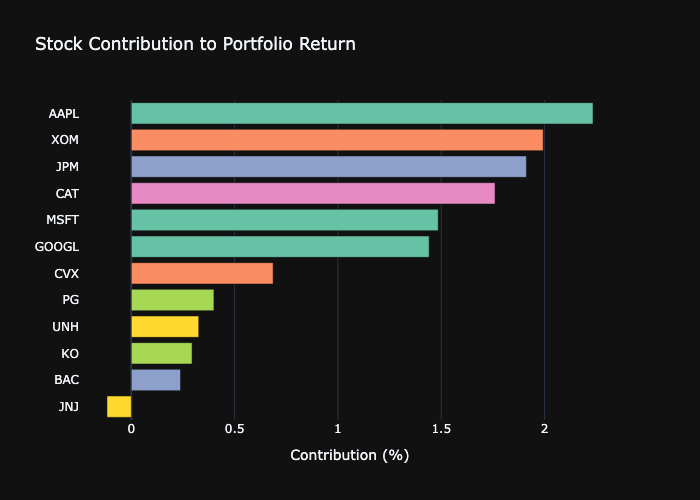

In [17]:
# Stock contribution waterfall
sorted_stocks = stock_df.sort_values('Contribution', ascending=True).index.tolist()

fig = go.Figure(go.Bar(
    x=stock_df.loc[sorted_stocks, 'Contribution'],
    y=sorted_stocks,
    orientation='h',
    marker_color=[px.colors.qualitative.Set2[list(stock_df['Sector'].unique()).index(s) % 8] 
                  for s in stock_df.loc[sorted_stocks, 'Sector']]
))

fig.update_layout(
    title='Stock Contribution to Portfolio Return',
    xaxis_title='Contribution (%)',
    template='plotly_dark',
    height=500
)
fig.show()


## 6. Rolling Attribution

In [18]:
# Rolling 60-day alpha
window = 60

rolling_alpha = []
rolling_beta = []
rolling_dates = []

for i in range(window, len(port_excess)):
    y = port_excess.iloc[i-window:i].values
    X = factors.iloc[i-window:i].values
    beta, _ = ols_regression(y, X)
    rolling_alpha.append(beta[0] * 252 * 100)  # Annualized alpha
    rolling_beta.append(beta[1])  # Market beta
    rolling_dates.append(port_excess.index[i])

rolling_df = pd.DataFrame({
    'Alpha': rolling_alpha,
    'Beta': rolling_beta
}, index=rolling_dates)


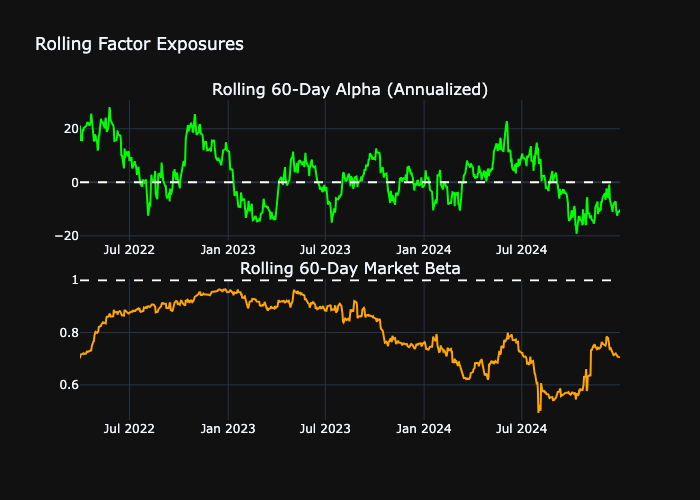

In [19]:
# Rolling alpha and beta chart
fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=['Rolling 60-Day Alpha (Annualized)', 'Rolling 60-Day Market Beta'],
    vertical_spacing=0.12
)

fig.add_trace(
    go.Scatter(x=rolling_df.index, y=rolling_df['Alpha'],
               mode='lines', name='Alpha', line=dict(color='lime')),
    row=1, col=1
)
fig.add_hline(y=0, line_dash="dash", line_color="white", row=1, col=1)

fig.add_trace(
    go.Scatter(x=rolling_df.index, y=rolling_df['Beta'],
               mode='lines', name='Beta', line=dict(color='orange')),
    row=2, col=1
)
fig.add_hline(y=1, line_dash="dash", line_color="white", row=2, col=1)

fig.update_layout(
    title='Rolling Factor Exposures',
    template='plotly_dark',
    height=500,
    showlegend=False
)
fig.show()


## 7. Summary Report

In [ ]:
print("="*70)
print("PERFORMANCE ATTRIBUTION REPORT")
print("="*70)

print(f"\n1. TOTAL RETURN")
print(f"   Portfolio: {port_cumulative.iloc[-1]*100:+.1f}%")
print(f"   Benchmark: {bench_cumulative.iloc[-1]*100:+.1f}%")
print(f"   Active:    {active_return.iloc[-1]*100:+.1f}%")

print(f"\n2. BRINSON ATTRIBUTION (Annualized)")
print(f"   Allocation:  {total_allocation:+.0f} bps")
print(f"   Selection:   {total_selection:+.0f} bps")
print(f"   Interaction: {total_interaction:+.0f} bps")

print(f"\n3. FACTOR ATTRIBUTION")
print(f"   Alpha: {betas[0]*252*100:+.2f}%")
print(f"   Market Beta: {betas[1]:.2f}")
print(f"   R²: {r2:.1%}")

print(f"\n4. TOP CONTRIBUTORS")
# Convert Contribution column to numeric for sorting
stock_df_numeric = stock_df.copy()
stock_df_numeric['Contribution'] = pd.to_numeric(stock_df_numeric['Contribution'], errors='coerce')
top3 = stock_df_numeric.nlargest(3, 'Contribution')
for sym in top3.index:
    print(f"   {sym}: {top3.loc[sym, 'Contribution']:.1f}% contribution")

print(f"\n5. SECTOR TILTS")
for sector in port_sector_weights.index:
    diff = (port_sector_weights[sector] - benchmark_sectors.get(sector, 0.05)) * 100
    if abs(diff) > 2:
        print(f"   {sector}: {diff:+.0f}% vs benchmark")

print("\n" + "="*70)


PERFORMANCE ATTRIBUTION REPORT

1. TOTAL RETURN
   Portfolio: +40.6%
   Benchmark: +28.2%
   Active:    +12.4%

2. BRINSON ATTRIBUTION (Annualized)
   Allocation:  +0 bps
   Selection:   +2 bps
   Interaction: +1 bps

3. FACTOR ATTRIBUTION
   Alpha: +0.17%
   Market Beta: 0.83
   R²: 85.3%

4. TOP CONTRIBUTORS
   AAPL: 2.2% contribution
   XOM: 2.0% contribution
   JPM: 1.9% contribution

5. SECTOR TILTS
   Consumer: +3% vs benchmark
   Energy: +9% vs benchmark
   Financials: +2% vs benchmark
   Healthcare: +2% vs benchmark
   Technology: +8% vs benchmark



: 

## Summary

This CQF-level example covered:

1. **Total Return Attribution**: Portfolio vs benchmark
2. **Brinson Attribution**: Allocation + Selection + Interaction
3. **Factor Attribution**: Fama-French 5-factor decomposition
4. **Stock-Level Attribution**: Individual position contributions
5. **Rolling Analysis**: Time-varying alpha and beta

**Family Office Applications**:
- Client reporting
- Manager evaluation
- Investment committee presentations
- Risk budgeting decisions